# Lesson 3: Vector Data with Shapely and Geopandas

In this lesson, we will explore how to work with vector data using the Shapely and GeoPandas Python libraries.

Vector data is one type of spatial data that we commonly encounter in science, alongside gridded (or raster) data that we'll cover in the next lesson.

Shapely provides a wealth of tools to create and work with vector geometries. Leveraging the tools provided by Shapely, GeoPandas allows us to work with spatial data and perform spatial operations in a tabular format just like pandas. GeoPandas builds off pandas so some concepts should hopefully feel like a natural progression from what we have already learned.

### Learning outcomes

After this lesson, you should be able to:


1) Create basic vector geometry objects using shapely.
2) Apply shapely to obtain key geospatial attributes from vector geometry objects.   
3) Understand the components of a GeoDataFrame and its similarities and differences from a pandas DataFrame.
4) Identify the appropriate GeoPandas functions to perform a range of spatial vector operations.
5) Explain when it is necessary to convert vector data between geographic and projected Coordinate Reference Systems.

:::{danger}
## Entry ticket!

This is your ticket into the lesson. Before we start, discuss with your neighbor for 1 minute the concept you found the most challenging from the last lesson.
:::

## Intro to spatial and vector data

Spatial data, as defined by software firm [Safe](https://www.safe.com/what-is/spatial-data/) is:

> a term used to describe any data related to or containing information about a specific location on the Earth’s surface

As earth scientists we are all about the earth's surface! Our data is inherently spatial.  Very little (or nothing) that we do is disconnected from location.  Learning how to deal with location, then, is a key part of learning to code for earth science research.

### Vector data vs. Raster data

Spatial data is most often divided between two types: 
1. **Vector data**: data storing discrete boundaries with attached attributes.
2. **Raster data**: made up of a continuous matrix of cells that each hold specific values.

![raster_v_vector](images/raster_v_vector.jpg)

_[Figure from Dr Ali Raza via Milan Jonosoz](https://www.facebook.com/milanjanosovscience/posts/a-regular-reminder-on-vector-vs-raster-data-with-an-infographic-by-dr-ali-raza%F0%9D%90%95%F0%9D%90%9E/801112299739827/)_

:::{admonition}

### Exercise 1: Spatial data structures

What is the best type of data structure for each dataset? Vector or raster. Spend 2 minutes on your own then another 1 minute discussing with your neighbor. 

1. temperature output from a weather model of spatitially continuous temperature predicitions
2. temperature taken from individual ground stations
4. whole air samples taken on an airplane flight
5. elevation across an entire state

:::

## Vector geometries and Shapely

**Shapely** is a Python library for creating, manipulating, and analyzing vector geometries such as **points, lines, and polygons**. It provides a simple way to perform common spatial operations, including calculating areas and distances, testing whether features intersect, and creating buffers around geographic features. 

Shapely is widely used in geospatial data science and forms the geometric foundation of many higher-level tools, including GeoPandas (coming up next!).

Here are some of the **types of vector geometries we might encounter:**

![pnt_line_poly](images/pnt_line_poly.png)

_[Figure from National Ecological Observatory Network (NEON) via UW-Madison](https://uw-madison-datascience.github.io/organization-geospatial/02-intro-vector-data/index.html)_

And here are some examples of these same **vector geometries using Shapely:**

| Geometry Type | Shapely Code Example | Example |
|---------------|---------------------|----------------------|
| Point | `Point(-95.37, 29.76)` | Rain gauge or weather station location |
| LineString | `LineString([(0, 0), (1, 1), (2, 1)])` | River channel or stream network |
| Polygon | `Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])` | Watershed boundary, lake, or field |
| MultiPoint | `MultiPoint([(0, 0), (1, 1), (2, 2)])` | Collection of monitoring stations |
| MultiLineString | `MultiLineString([[(0, 0), (1, 1)], [(2, 0), (2, 2)]])` | Multiple river segments |
| MultiPolygon | `MultiPolygon([poly1, poly2])` | Protected ecological areas consisting of multiple separate (non-contiguous) regions |


## Bounding boxes

One other important type of vector data that we commonly use in earth sciences are **bounding boxes.** Bounding boxes represent the **minimum and maxiumum coordinates** of the vector geomtries.  These are often latitude and longitude lines, but the bounding box is given the units of whatever dataset the raster is using.  AVIRIS, for example, uses a Universal Transverse Mercator (UTM) grid (more on this later) so the units of the bounding box are meters.

Look at this example for Italy. The country outline is shown in red and its bounding box is shown in black. Note how the box follows the minimum and maximum latitude and longitude lines:

![bounding](images/bounding_box.png)

Bounding boxes are often written as a list of coordinates in the format `[minimum_x minimum_y maximum_x maximum_y]`.  So for our Italy example the bounding box would be `[6.634, 36.62, 18.511, 47.08]`. Sometimes, we need to **translate between north/south/east/west and x/y coordinates:**

| Bounding Box Coordinate | Meaning |
|------------------------|---------|
| `minimum_x` | Western edge (left boundary) |
| `minimum_y` | Southern edge (bottom boundary) |
| `maximum_x` | Eastern edge (right boundary) |
| `maximum_y` | Northern edge (top boundary) |

## Using shapely to create geometries

In [1]:
from shapely.geometry import Point, LineString, Polygon, box

POINT (0 0)
Coordinates: [(4.0, 3.0)]
Plot:


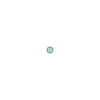

In [5]:
# Create point from x, y coordinates
point = Point(0.0, 0.0)
print(point)

# Print coordinates - note this is an attribute
print('Coordinates:', list(Point(4,3).coords))

# And best of all! Shapely geometries can be automatically visualized as shapes
print('Plot:')
point

In [6]:
# Calculate distance between two points
print('Distance:', Point(0,0).distance(Point(3,4)))

Distance: 5.0


0.5
3.414213562373095
(0.0, 0.0, 1.0, 1.0)


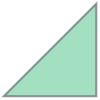

In [7]:
# Create a triangle shaped polygon
polygon = Polygon([(0, 0), (1, 1), (1, 0)])

# When you create a `Polygon` object you get extra properties that tell you something about your object
print(polygon.area)
print(polygon.length)
print(polygon.bounds)

polygon

POLYGON ((20 -15, 20 -5, 10 -5, 10 -15, 20 -15))
(10.0, -15.0, 20.0, -5.0)
Same box using *bounds:
POLYGON ((20 -15, 20 -5, 10 -5, 10 -15, 20 -15))


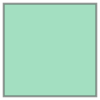

In [9]:
# Creating a Bounding Box
# When we create a bounding box in code the order of inputs is:
# `minx`, `miny`, `maxx`, `maxy`
first_box = box(10, -15, 20, -5)
print(first_box)
print(first_box.bounds)

# Bonus: use * to "unpack" the list
print('Same box using *bounds:')
xmin, ymin, xmax, ymax = 10, -15, 20, -5
bounds = [xmin, ymin, xmax, ymax] # list
same_box = box(*bounds)
print(same_box)

same_box

:::{admonition} Vocabulary: Unpacking (*)

The * operator can be used to unpack the values in a list or tuple and pass them as separate arguments to a function. This is useful when coordinates or other values are already stored together in a list or tuple.

```
bounds = [10, -15, 20, -5] # also works with tuple (10, -15, 20, -5)
box(*bounds)
```

is equivalent to:

```
box(10, -15, 20, -5)
```

:::

:::{admonition}

### Exercise 2: Shapely vector geometries

Spend 5 minutes writing code to perform these tasks.

1. Create a Shapely `Point` object representing the approximate location of Rome using the coordinates:
- Longitude: 12.5
- Latitude: 41.9

2. Create a bounding box for Italy using coordinates in the image above. Print the area of the bounding box.
3. Calculate distance between the northeast corner of the Italy bounding box and Rome.

:::

## GeoPandas

Sometimes we need to read in existing spatial data rather than create new vector geometries. Enter: **GeoPandas**. 

GeoPandas is an extension of pandas that uses shapely behind the scenes. Instead of `DataFrames`, GeoPandas uses... `GeoDataFrames`. `GeoDataFrames` have the same row, column structure with indexes that are accessed in the same way as pandas. The difference is that `GeoDataFrames` also have a `geometry` column.

You can think of GeoDataFrames as:
> GeoDataFrame = pandas DataFrame + geometry column of shapely objects 

![Geodataframe](images/geodataframe.png)

One great feature of the geodataframes is that they have a `.plot()` method that can be used to view the general distribution of data.

In [15]:
# Let's use some geopandas!
import pandas as pd
import geopandas as gpd

# This line shortens the output
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 20)

In [16]:
# Read in shapefile of California counties
# Available from: https://data.ca.gov/dataset/ca-geographic-boundaries
ca_counties = gpd.read_file('./data/CA_Counties.shp')

# attributes - columns
print('Columns:', ca_counties.columns)

# number of rows
print('N rows:', len(ca_counties))

# Info
print(ca_counties.info())

# Show first 5 rows
ca_counties.head()

Columns: Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')
N rows: 58
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   STATEFP     58 non-null     object  
 1   COUNTYFP    58 non-null     object  
 2   COUNTYNS    58 non-null     object  
 3   GEOID       58 non-null     object  
 4   NAME        58 non-null     object  
 5   NAMELSAD    58 non-null     object  
 6   LSAD        58 non-null     object  
 7   CLASSFP     58 non-null     object  
 8   MTFCC       58 non-null     object  
 9   CSAFP       31 non-null     object  
 10  CBSAFP      45 non-null     object  
 11  METDIVFP    7 non-null      object  
 12  FUNCSTA

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,06,091,00277310,06091,Sierra,Sierra County,06,H1,G4020,None,None,None,A,2.468695e+09,2.329911e+07,+39.5769252,-120.5219926,375602.758281,4.200450e+09,"POLYGON ((-13431319.751 4821511.426, -13431312..."
1,06,067,00277298,06067,Sacramento,Sacramento County,06,H1,G4020,472,40900,None,A,2.499984e+09,7.542543e+07,+38.4500161,-121.3404408,406584.174167,4.205516e+09,"POLYGON ((-13490651.476 4680831.603, -13490511..."
2,06,083,00277306,06083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,42200,None,A,7.084063e+09,2.729752e+09,+34.5370572,-120.0399729,891686.747247,1.449841e+10,"MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,06,009,01675885,06009,Calaveras,Calaveras County,06,H1,G4020,None,None,None,A,2.641785e+09,4.384187e+07,+38.1838996,-120.5614415,367005.879680,4.356213e+09,"POLYGON ((-13428575.483 4627725.227, -13428534..."
4,06,111,00277320,06111,Ventura,Ventura County,06,H1,G4020,348,37100,None,A,4.771988e+09,9.473454e+08,+34.3587415,-119.1331432,527772.242190,8.413293e+09,"MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


<Axes: >

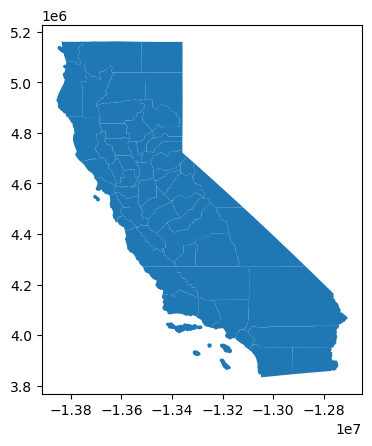

In [17]:
# Quick visualization is easy with geopandas - woo!
ca_counties.plot()

<Axes: >

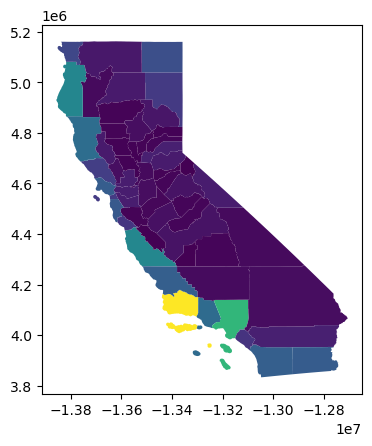

In [19]:
# A sneak preview of plotting! More on this in our plotting lesson

# Fill counties by their area that is water (an existing column in the data)
ca_counties.plot(column='AWATER')

## GeoDataFrame filtering, aggregations, and attributes 

We won't practice them now, but the point to note is: the filtering and aggregations we learned for DataFrames equally apply to GeoDataFrames. Briefly, recall:

* **Filtering and slicing:** using `iloc` (indexing by integer position) and `loc` (indexing by column or row names/labels).
* **Aggregations:** `min()`, `max()`, `sum()` etc.

GeoDataFrames also have all the same **attributes** as pandas DataFrames but additionly have a bunch of special **spatial attributes** (we have seen a few already). Recall that attributes are properties of objects that can often tell us really helpful information. Some of these spatial attributes include:

| Attribute | Purpose |
|-----------|---------|
| `.geometry` | Access the geometry column |
| `.bounds` | Get the bounding box of a geometry |
| `.total_bounds` | Get the overall bounding box of all geometries in the GeoDataFrame |
| `.area` | Calculate feature areas |
| `.centroid` | Find feature centers |
| `.geom_type` | Identify whether features are Points, Lines, or Polygons |
| `.x` | X coordinates of Point geometries | `gdf.geometry.x` |
| `.y` | Y coordinates of Point geometries | `gdf.geometry.y` |
| `.crs` | View the coordinate reference system (more on this later!) |

In [20]:
# The geometry of each county
ca_counties.geometry

0     POLYGON ((-13431319.751 4821511.426, -13431312...
1     POLYGON ((-13490651.476 4680831.603, -13490511...
2     MULTIPOLYGON (((-13440081.316 4150394.004, -13...
3     POLYGON ((-13428575.483 4627725.227, -13428534...
4     MULTIPOLYGON (((-13283668.94 4059436.934, -132...
                            ...                        
53    POLYGON ((-13646335.912 4521323.747, -13646300...
54    POLYGON ((-13677924.003 5161573.734, -13677618...
55    POLYGON ((-13605100.49 4469147.157, -13605081....
56    POLYGON ((-13680158.035 4814470.618, -13680202...
57    POLYGON ((-13490260.152 4272335.748, -13490212...
Name: geometry, Length: 58, dtype: geometry

:::{admonition}

### Exercise 3: GeoDataFrame attributes

Using the California counties GeoDataFrame:

1. Determine the geometry types present (__advanced hint:__ DataFrames and GeoDataFrames have a helpful function `.unique()` you may wish to also use).

2. Find the overall bounding box of California counties and identify the below (note that these numbers are in meters so don't worry if they don't look like your usual coordinates - more on this later!):

   - the westernmost longitude
   - the southernmost latitude
   - the easternmost longitude
   - the northernmost latitude

3. Find the area of the largest county (__hint:__ recall `.max()` from our DataFrame aggregations lesson).

:::

:::{dropdown}
### Answers

1. `ca_counties.geom_type.unique()`

Polygon, MultiPolygon

2. `ca_counties.total_bounds`

-13857274.7299,   3832930.6171, -12705029.5695,   5162403.8432

3. `ca_counties.area.max()`

77493035905.25322 # m2 (since our CRS is in meters)
:::

::::{hint}
## File formats: Shapefile, GeoJSON, WKT

We just read in a vector file using geopandas. Did you notice the file format? `.shp`?

This is an example of a shapefile. Shapefiles are a really common way to move shapes around that stores geographic features in a set of linked files (`.shp`, `.shx`, `.dbf`). There's some GIS background to shapefiles that we won't cover. For now, just take note this is one common format for vector data.

Other common formats for vector data include GeoJSON and WKT, which are both text-based representations. GeoJSON is a specific flavor of the very common JSON format (that we saw in the first lesson). Recall, JSON format is a way of sending data that looks just like a Python dictionary but it is used much more broadly than just Python. WKT stands for "Well Known Text".  It is another way of saving vector geometries. GeoJSON and WKT can be opened and read in a text editor, while shapefiles cannot because the geometry data are stored in binary format.

| Format | Storage Type | Human-readable? | Example |
|----------|-------------|----------------|---------|
| Shapefile | Binary, multi-file | No | `counties.shp`, `counties.dbf`, `counties.shx` |
| GeoJSON | Text (JSON) | Yes | `{"type":"Point","coordinates":[-120,38]}` |
| WKT | Text (plain string) | Yes | `POINT (-120 38)` |

#### Reading and writing vector files with GeoPandas

All of the common vector file formats can typically be read using geopandas function `gpd.read_file()`. Geopandas should automatically detect the format and use the right "driver" to open and read the data. Occasionally though, it is necessary to tell geopandas which driver it should use.

Like pandas (`to_csv()`), GeoPandas provides an easy way to write out (save / export) vector data. Example

```
counties.to_file('counties.shp', driver='ESRI Shapefile')
```

Further reading on GeoJSON:
* [geojson.org](https://geojson.org/) - the full specification
* [geojson.tools](https://geojson.tools/) - quick visualization of geojson objects

:::

o  or inspect attributes## Spatial operations 

Usually, we don't just want to look at spatial data on a map or inspect attributes, but perform some level of analysis. Just like addition or multiplication are operations for numbers, we also have operations we can run on spatial data which are unique.  What are some of the most common operations we might want to perform?

<img src="https://docs.qgis.org/2.8/en/_images/overlay_operations.png">

Another common one is a buffer: 
<img src="https://saylordotorg.github.io/text_essentials-of-geographic-information-systems/section_11/5c7eb6fc4bcbfc5117d778f0aabfded6.jpg" width=550>

:::{admonition}

### Exercise 4: Spatial vector operations

Which vector operation from these options would you use for each of the below?

Pick from:

a) Union

b) Intersects

c) Difference

1. You have a polygon showing a watershed boundary and a layer of biome polygons. You want to identify which biomes occur within the watershed.

2. You have a map of soil types and a map of land-use categories. You want to find the areas that have _both_ sand soil type and are used for livestock grazing.

3. Can you think of one Earth science application of the "difference" operation?

:::


## GeoDataFrame functions/methods 

Under the hood, GeoPandas uses Shapely to perform geometric operations. This means that many spatial operations in GeoPandas, such as calculating areas, finding centroids, creating buffers, or testing whether features intersect, rely on the geometry objects and functions provided by Shapely. GeoPandas combines these spatial capabilities with the familiar tabular operations of pandas.

| Function/Method | Description | Example |
|----------|-------------|---------|
| `.dissolve()` | Dissolve multiple features into single geometry feature  | `.dissolve()` |
| `.buffer()` | Create a buffer around geometries | `.buffer(1000)` |
| `.intersects()` | Test whether geometries overlap another geometry | `.intersects(poly)` |
| `.contains()` | Test whether geometries contain another geometry | `.contains(point)` |
| `.distance()` | Calculate distance to another geometry | `.distance(point)` |
| `.clip()` | Clip features to a boundary | `.clip(boundary)` |
| `gpd.sjoin()` | Perform a spatial join between datasets | `.sjoin(points, polygons)` |
| `gpd.overlay()` | Perform spatial overlay operations | `.overlay(gdf1, gdf2)`, use `how=difference` to change the type of operation (`union`, `intersection`)|

## A whistlestop tour of georeferencing, Coordinate Reference Systems, and EPSG codes

So far we have worked with some spatial vector data without paying attention to its georeferencing. **Georeferencing** is the process of assigning a data value a location in space. Without georeferencing, spatial datasets are just pretty images that could have been taken anywhere in the world, or not on this world at all.

To correctly assign locations in space, we need to specify the **Coordinate Reference Systems** (CRS), the system that lets us lay out our 2D surface representing the earth (a map) so we can refer to points on that surface. The units of a CRS will be a piece of information that you use frequently when working with spatial data. For example, knowing what type of CRS you are using is important for measuring distances: datasets in **meters** make more sense for distances and areas that data in **degrees**, despite degres usually being more intuitive to think of data in latitude and longitudes. 

One common way to communicate this to a computer is using **EPSG codes**. These codes assign an integer number to many of the common map projection and CRS combinations. The epsg.io page contains plentiful info about the units of each projection. For example, try www.epsg.io/4326. 

CRS fit into two main categories:
| CRS Type | Units | Common Uses | Example |
|----------|--------|-------------|---------|
| Geographic CRS | Degrees | Storing global coordinates and locations | Latitude/longitude (`EPSG:4326`) |
| Projected CRS | Meters, kilometers, feet, miles, etc. | Measuring area, distance, and length | UTM (`EPSG:32610`), Web Mercator (`EPSG:3857`) |







:::{admonition}

### Exercise 4: Spatial vector operations

Which vector operation from these options would you use for each of the below?

Pick from:

a) Union

b) Intersects

c) Difference

1. You have a polygon showing a watershed boundary and a layer of biome polygons. You want to identify which biomes occur within the watershed.

2. You have a map of soil types and a map of land-use categories. You want to find the areas that have _both_ sand soil type and are used for livestock grazing.

3. Can you think of one Earth science application of the "difference" operation?

:::


## GeoDataFrame functions/methods 

Under the hood, GeoPandas uses Shapely to perform geometric operations. This means that many spatial operations in GeoPandas, such as calculating areas, finding centroids, creating buffers, or testing whether features intersect, rely on the geometry objects and functions provided by Shapely. GeoPandas combines these spatial capabilities with the familiar tabular operations of pandas.

| Function/Method | Description | Example |
|----------|-------------|---------|
| `.dissolve()` | Dissolve multiple features into single geometry feature  | `.dissolve()` |
| `.buffer()` | Create a buffer around geometries | `.buffer(1000)` |
| `.intersects()` | Test whether geometries overlap another geometry | `.intersects(poly)` |
| `.contains()` | Test whether geometries contain another geometry | `.contains(point)` |
| `.distance()` | Calculate distance to another geometry | `.distance(point)` |
| `.clip()` | Clip features to a boundary | `.clip(boundary)` |
| `gpd.sjoin()` | Perform a spatial join between datasets | `.sjoin(points, polygons)` |
| `gpd.overlay()` | Perform spatial overlay operations | `.overlay(gdf1, gdf2)`, use `how=difference` to change the type of operation (`union`, `intersection`)|

## Spatial filtering: FIREX data example

Let's work with some real world scientific spatial data from FIREX and briefly explore spatial filtering (like index filtering but now leveraging the spatial geometry properties we have available to use with geopandas). 

This time we will load from tabular data using pandas and convert this to a GeoDataFrame using some neat geopandas functionality.

In [70]:
# Import the libary - you only have to do this once per file
import pandas as pd

# To open excel data, we'll first need to install an extra package dependency
!pip install openpyxl -qq

In [76]:
# Here we will read using pandas and then convert to geodataframe
firex_filepath = "./data/SARP 2009 to 2020.xlsx"
firex = pd.read_excel(firex_filepath, 'data')

# Some data cleaning / preparation
firex = firex[['Can#', 'Jday', 'Latitude', 'Longitude', 'State', 'CH4 (ppmv)',
       'CO (ppbv)', 'CO2_ppm', 'OCS (MS)', 'DMS (MS)']].iloc[:4490]

# Drop columns where Latitude or Longitude are nan
firex = firex[firex['Longitude'].notna()]

# Replace both nan values with np.nan
firex = firex.replace({-999: np.nan, -888: np.nan})

firex.head()

,Can#,Jday,Latitude,Longitude,...,CO (ppbv),CO2_ppm,OCS (MS),DMS (MS)
0,8198,202.0,35.000000,-118.943333,...,NaN,NaN,518.0,NaN
1,7167,202.0,35.081667,-119.101000,...,NaN,NaN,519.0,NaN
2,6354,202.0,35.170000,-119.233333,...,NaN,NaN,495.0,14.0
3,7226,202.0,35.346667,-119.381667,...,NaN,NaN,505.0,11.9
4,6269,202.0,35.438333,-119.433333,...,NaN,NaN,487.0,17.4


,Can#,Jday,Latitude,Longitude,...,CO (ppbv),CO2_ppm,OCS (MS),DMS (MS)
0,8198,202.0,35.000000,-118.943333,...,NaN,NaN,518.0,NaN
1,7167,202.0,35.081667,-119.101000,...,NaN,NaN,519.0,NaN
2,6354,202.0,35.170000,-119.233333,...,NaN,NaN,495.0,14.0
3,7226,202.0,35.346667,-119.381667,...,NaN,NaN,505.0,11.9
4,6269,202.0,35.438333,-119.433333,...,NaN,NaN,487.0,17.4


<Axes: >

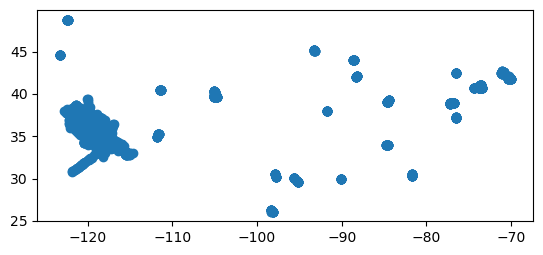

<Axes: >

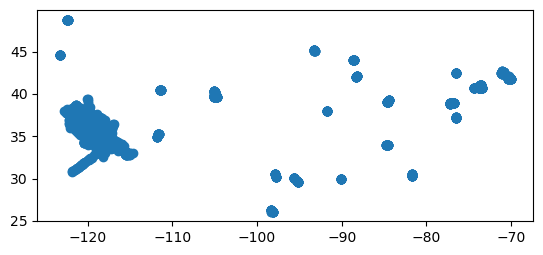

In [77]:
# Use a neat gpd function gpd.points_from_xy to convert to geodataframe using the lat/lon info
geoFIREX = gpd.GeoDataFrame(firex, geometry=gpd.points_from_xy(firex['Longitude'], firex['Latitude']))

geoFIREX.plot()

In [78]:
# Convert to a projected CRS so we can measure distances/areas in meters
geoFIREX_projected = geoFIREX.to_crs(epsg=3857)

ValueError: Cannot transform naive geometries.  Please set a crs on the object first.

:::{warning}
## Bug alert!

Oops! What happened?

`ValueError: Cannot transform naive geometries.  Please set a crs on the object first.`

We tried to convert the CRS before setting the CRS in the first place. Our computer doesn't know the original projection if we don't tell it what it is. We'll need to first use `set_crs()` before then converting with `to_crs()`.

:::

In [79]:
# Set the CRS, if you didn't do it when you read in the data
geoFIREX = geoFIREX.set_crs(epsg=4326)
geoFIREX.crs
geoFIREX.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [81]:
# Convert to Web mercator projection (EPSG:3857)
geoFIREX_projected = geoFIREX.to_crs(epsg=3857)
geoFIREX_projected.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [104]:
# The benefit is that our distances are now in m

# ellington = Point(-95.158, 29.607)  # in epsg4326, in degrees
ellington_projected = Point(-10592940, 3453132.7262827833) # in epsg3857, in meters

# Distance of first FIREX data point to where we are now
point = geoFIREX_projected.iloc[[0]]
print(point.distance(ellington) / 1000) # km

0    2741.506186
dtype: float64


Let's use our California counties from earlier and see how many of our FIREX data were collected in California.

Note we could have used shapely `transform` to do this reprojection for us:
```
from pyproj import Transformer
from shapely.ops import transform

ellington = Point(-95.158, 29.607)  # in epsg4326, in degrees
t = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True).transform
ellington_projected = transform(t, ellington)
```

<Axes: >

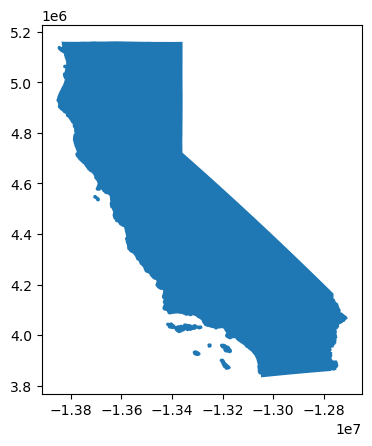

<Axes: >

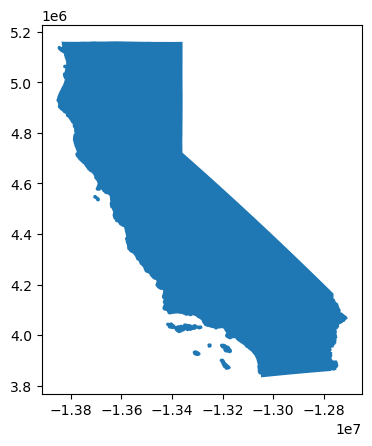

In [107]:
# Dissolve California counties to single state
ca = ca_counties.dissolve()
ca.plot()

In [114]:
# Check California and the geoFIREX data are in same projection
print(ca.crs)
print(geoFIREX_projected.crs)

# They match to that's great! 
# If not we would convert one of them to be the same as the other

# Filter the FIREX data by the California state polygon
# Using geopandas spatial join function, specifying within
FIREX_ca = gpd.sjoin(geoFIREX_projected, ca, predicate='within')
FIREX_ca.head()

EPSG:3857
EPSG:3857


,Can#,Jday,Latitude,Longitude,...,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area
0,8198,202.0,35.000000,-118.943333,...,+39.5769252,-120.5219926,375602.758281,4.200450e+09
1,7167,202.0,35.081667,-119.101000,...,+39.5769252,-120.5219926,375602.758281,4.200450e+09
2,6354,202.0,35.170000,-119.233333,...,+39.5769252,-120.5219926,375602.758281,4.200450e+09
3,7226,202.0,35.346667,-119.381667,...,+39.5769252,-120.5219926,375602.758281,4.200450e+09
4,6269,202.0,35.438333,-119.433333,...,+39.5769252,-120.5219926,375602.758281,4.200450e+09


In [117]:
# So it mostly looks the same, but let's see how many rows we now have

print('Total points:', len(geoFIREX_projected))

print('Points collected in California:', len(FIREX_ca))

Total points: 4405
Points collected in California: 3442


<Axes: >

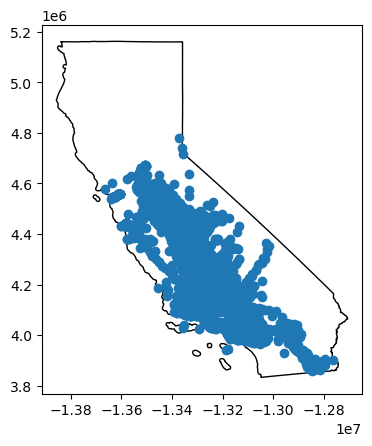

In [121]:
# And plot (it is spatial data after all!!)
import matplotlib.pyplot as plt # we will cover this in lesson 6
ca.plot(facecolor='none', edgecolor='black')
FIREX_ca.plot(ax=plt.gca()) # Don't worry about this for now

:::{danger}
## Exit ticket!

This is your ticket outta here. Before you leave this lesson, please submit your responses to the following questions using this link: INSERT LINK

* Give an overall rating of how much of this lesson's content you feel you are now comfortable with? Indicate on a 0-10 scale, with 10 being you are comfortable with all of the content.
* How was the pace of this lesson for you? 1) Too slow; 2) About right; 3) Too fast.
* Briefly, what was the single concept you found most challenging in this lesson? 

:::

:::{hint}
## Further reading

* Getting started with GeoPandas: https://geopandas.org/en/stable/getting_started/introduction.html
* More GeoPandas: https://realpython.com/geopandas/
* GeoPandas example: https://learning.nceas.ucsb.edu/2023-03-arctic/sections/geopandas.html\



:::

# PARKING LOT

Another built-in method for viewing data is `.explore()`. In order to use `.explore()` the dataframe must have a CRS (coordinate reference system) set. For more features with the `.explore()` method check out [the geopandas user guide](https://geopandas.org/en/stable/docs/user_guide/interactive_mapping.html). You can see the available basemaps on [the docs page](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.explore.html) for `.explore()` under the `tiles` argument.

| `.set_crs()` | Set CRS of the geometries | `.set_crs("EPSG:4326")` |
| `.to_crs()` | Reproject geometries to a new CRS | `.to_crs("EPSG:3857")` |

## Recap

Before we progress with pandas and GeoPandas, let's recap our understanding.

Could swap this exercise 2 with the picarro flight example, bit more involved but real world data.

:::{admonition}
### Exercise 2: DataFrame filtering definitions - TO UPDATE

1. Which of these would you use if you wanted the third row of a dataframe: `loc` or `iloc`?

2. Which of these gets you a slice of a dataframe: `iloc[5]` or `iloc[5:8]`?

3. Which of these would you use to get rows of a dataframe where elevation is over 300 meters: `loc` or `iloc` or `[]`?

:::

:::{admonition}
### Exercise 3: DataFrame filtering and aggregation practice - could replace with picarro flight data

Using the dataframe provided below, find answers for the following:

1. Get the median wind speed.

2. Get the modal (most commonly occurring) temperature.

3. Get temperature, humidity, and wind speed from the final row (`iloc()`).

4. Get maximum humidity on days where temperature was below 30 C.

5. Get the mean wind speed between July 3 and July 6. You may want to first set time as the index (`set_index()`).

```
import pandas as pd

# Let's create a data frame using some fake data in a dictionary
forecast_dict = {
    'time': ['2025-07-01', '2025-07-02', '2025-07-03', '2025-07-04', '2025-07-05', '2025-07-06', '2025-07-07'],
    'temperature': [25, 20, 27, 31, 32, 32, 28], 
    'humidity': [60, 65, 62, 80, 78, 76, 74],
    'wind_speed': [10, 9, 10, 6, 4, 3, 4]
}
forecast = pd.DataFrame(forecast_dict)
forecast
```
:::